# Grise Fiord from space

## The site

The PRECIPICE GNSS-IR sensor is in **Ausuittuq (Grise Fiord), Nunavut** (76.417 N, 82.896 W), the northernmost community in Canada. The shore-mounted instrument sits about 11 m above the water and looks SSW over **Jones Sound**, the channel between Ellesmere Island and Devon Island.

GNSS-IR uses GNSS signals reflected from the water surface to retrieve sea level. It is particularly useful in the Arctic, where conventional tide gauges are sparse, as Section 1 shows.

## What this notebook does

**Section 1** maps the site and the tide-gauge network around it.

**Sections 2 and 3** show how to find, download, and plot satellite products that describe the environment
at the site: sea-ice conditions and satellite measurements of sea surface height. Each section identifies
the collection, where it is served from, whether credentials are required, the minimum working code, and
common pitfalls.

**The GNSS-IR retrieval itself is not covered here.** That is documented in
[`gnssir_processing.ipynb`](gnssir_processing.ipynb).

### Sections

| Section | What | Login needed |
|---|---|---|
| **1. Site context map** | Canada-wide tide-gauge coverage + Jones Sound regional inset | no |
| **2.1-2.3 Sea-ice concentration** | Daily 25 km record at the site, and 25 km vs 6.25 km side by side | no |
| **2.4 ICESat-2** | ATL10 freeboard vs ATL07 surface height side by side | yes, free Earthdata Login |
| **3. SWOT** | Pull a KaRIn granule from PO.DAAC and map sea surface height over the site | yes, free Earthdata Login |

### Setup

```bash
git clone <this repo>
cd <repo>
conda env create -f environment.yml     # creates the "arctic-eo" env
conda activate arctic-eo
jupyter lab
```

Then pick the **arctic-eo** kernel. If you would rather use an environment you already have, you need
`numpy`, `pandas`, `matplotlib`, `xarray`, `netCDF4`, `h5py`, `pyproj`, `cartopy`, `rioxarray`, and
`earthaccess`.

Paths are all relative to the repo.

### Credentials

Sections 1 through 2.3 need none at all. Sections 2.4 and 3 need a free
[Earthdata Login](https://urs.earthdata.nasa.gov/users/new). Register, then the first
`earthaccess.login(persist=True)` prompts once and writes to `~/.netrc`, and every run after that is silent.
Do not put credentials in the notebook.

### What gets downloaded

| Dataset | Size | Saved to |
|---|---|---|
| Natural Earth vectors | ~40 MB | `data/natural_earth/` |
| Sea-ice CDR, 15 months daily | ~200 MB | `data/sea_ice/G02202_V6_north_daily/` |
| AMSR2 snapshot, one day | ~1 MB | `data/sea_ice/bremen_amsr2/` |
| ICESat-2 ATL10, 4 granules | ~400 MB | `data/sea_ice/icesat2_atl10/` |
| ICESat-2 ATL07, 4 granules | ~1.3 GB | `data/sea_ice/icesat2_atl07/` |
| SWOT, 1 granule | ~34 MB | `data/swot/` |

Every download cell skips files already on disk, so the data only needs to be downloaded once. The
ICESat-2 granules account for most of the download size.

---
## 0. Setup

Imports, the site coordinates, and the data directories. Each directory is created here and labelled with
the section that uses it, and the cell prints what it resolved so you can check before anything downloads.

One `pyproj` note. On some setups, notably conda environments launched from a kernel that inherited a stale
`PROJ_DATA` or `PROJ_LIB`, `pyproj` cannot find its PROJ database and every `Transformer` call dies with
`Internal Proj Error: proj_create: no database context specified`. The cell below tries a transform first
and only overrides the database path if that fails.


In [1]:
import os, sys, json, re, urllib.request, warnings
from pathlib import Path

# These two fire at import and print absolute environment paths into the saved output.
warnings.filterwarnings('ignore', message='pyproj unable to set database path')
warnings.filterwarnings('ignore', message='IProgress not found')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPoly, Patch, FancyBboxPatch
from matplotlib.collections import PatchCollection, LineCollection

import pyproj
def _fix_proj_datadir():
    # Only override if the default is genuinely broken. Try the env's share/proj, then the
    # copy pip ships inside the pyproj package. Returns the directory actually in use.
    for candidate in (None,
                      Path(sys.prefix) / 'share' / 'proj',
                      Path(pyproj.__file__).parent / 'proj_dir' / 'share' / 'proj'):
        if candidate is not None:
            if not (Path(candidate) / 'proj.db').exists():
                continue
            pyproj.datadir.set_data_dir(str(candidate))
        try:
            pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3413', always_xy=True).transform(-83, 76)
            return pyproj.datadir.get_data_dir()
        except Exception:
            continue
    raise RuntimeError('pyproj cannot find a working PROJ database. '
                       'Try: conda install -c conda-forge proj-data')
PROJ_DIR = _fix_proj_datadir()
from pyproj import Transformer, CRS

import xarray as xr

# ── paths: repo-relative, nothing machine-specific ──
# Jupyter's cwd is the notebook's own directory, so step up out of notebooks/ if that is where we are.
_here = Path.cwd().resolve()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
DATA_ROOT    = Path(os.environ.get('ARCTIC_EO_DATA', PROJECT_ROOT / 'data'))   # gitignored; set
                                                                              # ARCTIC_EO_DATA to cache elsewhere

NE_DIR   = DATA_ROOT / 'natural_earth'                       # section 1  vector basemaps
SEA_ICE  = DATA_ROOT / 'sea_ice'                             # section 2
CDR_DIR  = SEA_ICE / 'G02202_V6_north_daily'                 #   2.1  25 km daily concentration
BR_DIR   = SEA_ICE / 'bremen_amsr2'                          #   2.3  6.25 km AMSR2 snapshot
IS2_DIR  = SEA_ICE / 'icesat2_atl10'                         #   2.4  freeboard
A7_DIR   = SEA_ICE / 'icesat2_atl07'                         #   2.4  surface height
SWOT_DIR = DATA_ROOT / 'swot'                                # section 3
FIGS     = PROJECT_ROOT / 'figures'                          # figure output, safe to commit
for d in (NE_DIR, CDR_DIR, BR_DIR, IS2_DIR, A7_DIR, SWOT_DIR, FIGS):
    d.mkdir(parents=True, exist_ok=True)

# ── site ──
GF_LON, GF_LAT = -82.896439, 76.417075   # Google Earth estimate, swap in surveyed coords when available

from pyproj import Geod
_GEOD = Geod(ellps='WGS84')

def add_scalebar(ax, length_km, y=0.055, right=0.95, left=None, fontsize=9, lw=3.5):
    """Draw a scale bar on a cartopy map axis, right-aligned by default.

    The bar is drawn in the axis's projected metres, but its length is set from the true
    ground distance measured at the bar's own latitude, so it stays correct where the
    projection stretches away from its true-scale latitude.
    """
    import cartopy.crs as ccrs
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    by = y0 + (y1 - y0) * y
    probe = x0 + (x1 - x0) * 0.5
    lon_a, lat_a = ccrs.PlateCarree().transform_point(probe, by, ax.projection)
    lon_b, lat_b = ccrs.PlateCarree().transform_point(probe + 1e4, by, ax.projection)
    _, _, ground = _GEOD.inv(lon_a, lat_a, lon_b, lat_b)      # true m per 1e4 projected m
    bar = length_km * 1e3 * (1e4 / ground)
    bx = x0 + (x1 - x0) * left if left is not None else x0 + (x1 - x0) * right - bar
    for width, colour, z in ((lw + 3.5, 'white', 59), (lw, 'black', 60)):
        ax.plot([bx, bx + bar], [by, by], color=colour, lw=width, solid_capstyle='butt',
                transform=ax.projection, zorder=z, clip_on=False)
    ax.annotate(f'{length_km:g} km', xy=(bx + bar / 2, by), xycoords=ax.transData,
                xytext=(0, 7), textcoords='offset points', ha='center', va='bottom',
                fontsize=fontsize, fontweight='bold', zorder=61,
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.85))

def rel(p):
    "Path relative to the repo, so printed output is not tied to one machine."
    p = Path(p).resolve()
    try:    return str(p.relative_to(PROJECT_ROOT))
    except ValueError:
        try:    return '~/' + str(p.relative_to(Path.home()))
        except ValueError:  return str(p)

print(f'python  : {sys.version.split()[0]}')
print(f'proj db : {"ok" if Path(PROJ_DIR, "proj.db").exists() else "MISSING"}')
print(f'repo    : {PROJECT_ROOT.name}/')
print(f'data    : {rel(DATA_ROOT)}')
print(f'site    : {GF_LAT:.4f} N, {abs(GF_LON):.4f} W')

python  : 3.11.0
proj db : ok
repo    : mcgill-gnssir-satellite-work/
data    : data
site    : 76.4171 N, 82.8964 W


---
# 1. Where the site is

### Data sources

| Layer | Source | Access |
|---|---|---|
| Tide gauges | CHS Integrated Water Level System (IWLS) | [`api-iwls.dfo-mpo.gc.ca/api/v1/stations`](https://api-iwls.dfo-mpo.gc.ca/api/v1/stations), open JSON, no key |
| Country borders | Natural Earth `ne_110m_admin_0_countries` | [natural-earth-vector](https://github.com/nvkelso/natural-earth-vector/tree/master/geojson) on GitHub |
| Coastlines (regional) | Natural Earth `ne_10m_land` | same |
| Rivers | Natural Earth `ne_50m_rivers_lake_centerlines` | same |
| Bathymetry | Natural Earth `ne_10m_bathymetry_*`, bands at 0/200/1000/2000/3000/4000 m | same |

The Natural Earth files cache into `data/natural_earth/` on first download (about 40 MB all in), so this
is fast on re-runs.
The IWLS call is live every run, so the gauge counts in the legend update themselves.

### Projections

Left: Lambert Conformal Conic, with standard parallels at 49°N and 77°N and a central meridian at 95°W,
suited to the scale of Canada.

Right: Stereographic projection centred on the antenna, with negligible distortion at this scale.

In both panels, easting/northing ticks are omitted, and latitude/longitude lines are labelled along the
outer edges.

In [2]:
# ── 1a. Country-scale layers (Lambert Conformal Conic) ──

_NE_BASE = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson'

def fetch_ne(name):
    """Download a Natural Earth GeoJSON into the cache once, then read from disk."""
    path = NE_DIR / name
    if not path.exists():
        print(f'downloading {name} ...')
        urllib.request.urlretrieve(f'{_NE_BASE}/{name}', path)
    with open(path) as f:
        return json.load(f)

# CHS station list (live)
with urllib.request.urlopen('https://api-iwls.dfo-mpo.gc.ca/api/v1/stations', timeout=30) as r:
    stations = pd.DataFrame(json.loads(r.read()))
active   = stations[stations['operating'] == True].copy()
inactive = stations[stations['operating'] == False].copy()
print(f'{len(stations)} CHS stations: {len(active)} active, {len(inactive)} discontinued')

world  = fetch_ne('ne_110m_admin_0_countries.geojson')
rivers = fetch_ne('ne_50m_rivers_lake_centerlines.geojson')

# Shallow first so the deeper bands paint over them with darker colours
bathy_files = [
    ('ne_10m_bathymetry_L_0.geojson',    '#cfe1ee', '0-200 m'),
    ('ne_10m_bathymetry_K_200.geojson',  '#a8c8de', '200-1000 m'),
    ('ne_10m_bathymetry_J_1000.geojson', '#7ea7c4', '1000-2000 m'),
    ('ne_10m_bathymetry_I_2000.geojson', '#5b8aab', '2000-3000 m'),
    ('ne_10m_bathymetry_H_3000.geojson', '#3f6e8e', '3000-4000 m'),
    ('ne_10m_bathymetry_G_4000.geojson', '#2c5575', '> 4000 m'),
]
bathy_layers = [(fetch_ne(n), c, lbl) for n, c, lbl in bathy_files]

lcc = pyproj.CRS.from_proj4('+proj=lcc +lat_1=49 +lat_2=77 +lat_0=63 +lon_0=-95 '
                            '+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs')
tr = Transformer.from_crs('EPSG:4326', lcc, always_xy=True)

def outer_rings(feat):
    """Exterior ring(s) of a GeoJSON feature. Holes are dropped; at this scale they do not matter."""
    g = feat['geometry']
    if g is None:                   return []
    if g['type'] == 'Polygon':      return [g['coordinates'][0]]
    if g['type'] == 'MultiPolygon': return [poly[0] for poly in g['coordinates']]
    return []

def project_ring(ring, transformer=tr):
    lons = [p[0] for p in ring]; lats = [p[1] for p in ring]
    xs, ys = transformer.transform(lons, lats)
    return list(zip(xs, ys))

def safe(pr, lim=1e8):
    """LCC blows up far from its centre. Drop any ring that lands in the millions of km."""
    return not any(abs(x) > lim or abs(y) > lim for x, y in pr)

_show = {'Canada', 'United States of America', 'Greenland', 'Mexico', 'Iceland', 'Russia'}
canada_patches, other_patches = [], []
for feat in world['features']:
    name = feat['properties'].get('NAME') or feat['properties'].get('name')
    if name not in _show:
        continue
    for ring in outer_rings(feat):
        pr = project_ring(ring)
        if safe(pr):
            (canada_patches if name == 'Canada' else other_patches).append(pr)

river_lines = []
for feat in rivers['features']:
    g = feat['geometry']
    if g is None:
        continue
    lines = ([g['coordinates']] if g['type'] == 'LineString'
             else g['coordinates'] if g['type'] == 'MultiLineString' else [])
    for line in lines:
        if not any(-170 < lon < -45 and 25 < lat < 85 for lon, lat in line):
            continue
        pl = project_ring(line)
        if safe(pl):
            river_lines.append(pl)

bathy_patches = []
for layer, color, label in bathy_layers:
    polys = []
    for feat in layer['features']:
        for ring in outer_rings(feat):
            if not any(-180 < lon < -30 and 20 < lat < 89 for lon, lat in ring):
                continue
            pr = project_ring(ring)
            if safe(pr):
                polys.append(pr)
    bathy_patches.append((polys, color, label))

act_x, act_y = tr.transform(active['longitude'].values, active['latitude'].values)
ina_x, ina_y = tr.transform(inactive['longitude'].values, inactive['latitude'].values)
gf_x_lcc, gf_y_lcc = tr.transform(GF_LON, GF_LAT)

ARCTIC_CIRCLE = 66.5633
n_arctic = int((active['latitude'] >= ARCTIC_CIRCLE).sum())
print(f'active CHS gauges above the Arctic Circle: {n_arctic} of {len(active)}')
print(f'country layers ready: {len(canada_patches)} Canada rings, '
      f'{len(other_patches)} other, {len(river_lines)} rivers')

1573 CHS stations: 145 active, 1428 discontinued
active CHS gauges above the Arctic Circle: 5 of 145
country layers ready: 30 Canada rings, 27 other, 287 rivers


In [3]:
# ── 1b. Jones Sound layers (local stereographic, centred on the antenna) ──

land = fetch_ne('ne_10m_land.geojson')
inset_bathy = [(fetch_ne(n), c) for n, c in [
    ('ne_10m_bathymetry_L_0.geojson',    '#cfe1ee'),
    ('ne_10m_bathymetry_K_200.geojson',  '#a8c8de'),
    ('ne_10m_bathymetry_J_1000.geojson', '#7ea7c4'),
    ('ne_10m_bathymetry_I_2000.geojson', '#5b8aab'),
]]

local_proj = pyproj.CRS.from_proj4(
    f'+proj=stere +lat_0={GF_LAT} +lon_0={GF_LON} +k_0=1 '
    '+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs')
ltr = Transformer.from_crs('EPSG:4326', local_proj, always_xy=True)

# Only project features near the site. The 10m files are big and this is most of the runtime.
_BBOX = dict(lon_min=-110, lon_max=-55, lat_min=70, lat_max=82)
def in_bbox(ring):
    return any(_BBOX['lon_min'] < lon < _BBOX['lon_max'] and
               _BBOX['lat_min'] < lat < _BBOX['lat_max'] for lon, lat in ring)

land_patches = []
for feat in land['features']:
    for ring in outer_rings(feat):
        if not in_bbox(ring):
            continue
        pr = project_ring(ring, ltr)
        if safe(pr, 5e7):
            land_patches.append(pr)

inset_bathy_patches = []
for layer, color in inset_bathy:
    polys = []
    for feat in layer['features']:
        for ring in outer_rings(feat):
            if not in_bbox(ring):
                continue
            pr = project_ring(ring, ltr)
            if safe(pr, 5e7):
                polys.append(pr)
    inset_bathy_patches.append((polys, color))

gf_x, gf_y = ltr.transform(GF_LON, GF_LAT)   # (0, 0) by construction, kept explicit for clarity
half_local = 500e3                            # half-width of the inset view, metres

print(f'inset layers ready: {len(land_patches)} land rings, '
      f'{sum(len(p) for p, _ in inset_bathy_patches)} bathymetry rings')

inset layers ready: 71 land rings, 96 bathymetry rings


### Geographic setting

The left panel covers Canada, the right zooms in on Jones Sound. The blue outline on the left marks the
right panel's extent.

Saves to `figures/canadian_tide_gauges_combined.png`.

/var/folders/89/l74gfpqj40z09y2mj3f1sw6h0000gn/T/ipykernel_1922/3247410761.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=0.1)


wrote figures/canadian_tide_gauges_combined.png


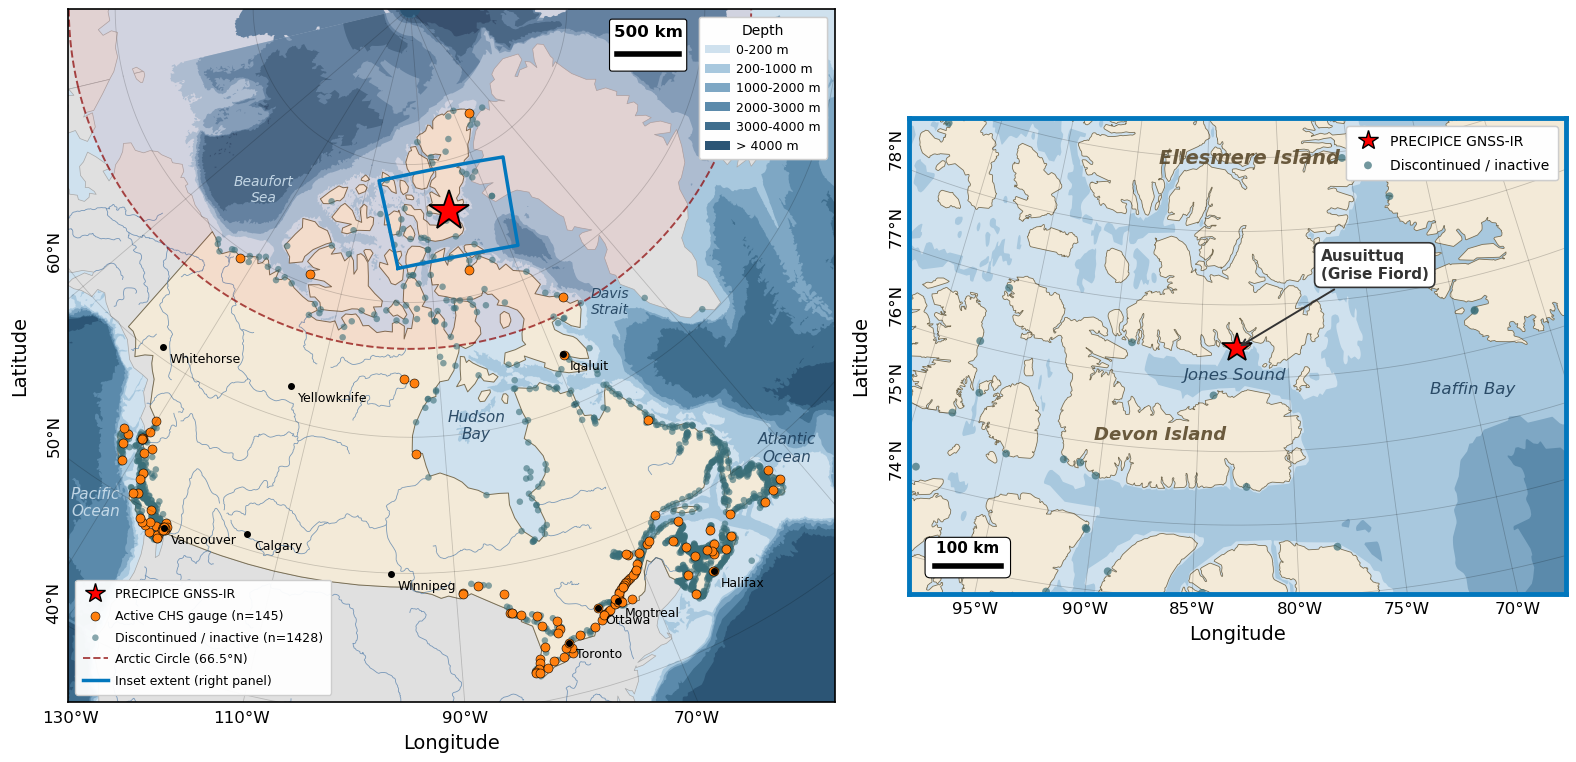

In [4]:
# ── 1c. Combined figure ──

_inv_local = Transformer.from_crs(local_proj, 'EPSG:4326', always_xy=True)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(20, 9),
                               gridspec_kw={'width_ratios': [1.3, 1], 'wspace': 0.05})

# ====================================================================
# LEFT: country-scale tide-gauge map (LCC)
# ====================================================================
axL.set_facecolor('#cfe1ee')

for z, (polys, color, _lbl) in enumerate(bathy_patches, start=1):
    axL.add_collection(PatchCollection(
        [MplPoly(p, closed=True) for p in polys],
        facecolor=color, edgecolor='none', zorder=z))

axL.add_collection(PatchCollection(
    [MplPoly(p, closed=True) for p in other_patches],
    facecolor='#e0e0e0', edgecolor='#a8a8a8', linewidth=0.5, zorder=10))
axL.add_collection(PatchCollection(
    [MplPoly(p, closed=True) for p in canada_patches],
    facecolor='#f3ead8', edgecolor='#7a6f55', linewidth=0.7, zorder=11))
axL.add_collection(LineCollection(river_lines, colors='#4a78a8',
                                  linewidths=0.6, alpha=0.7, zorder=12))

# Arctic Circle band + line
band_lons = np.linspace(-180, 180, 200)
circle_line_pts = [(lo, ARCTIC_CIRCLE) for lo in band_lons]
band_ring_pts = circle_line_pts + [(lo, 89.5) for lo in band_lons[::-1]]
axL.add_patch(MplPoly(project_ring(band_ring_pts), closed=True,
                      facecolor='red', alpha=0.06, edgecolor='none', zorder=13))
cx_, cy_ = zip(*project_ring(circle_line_pts))
arctic_h, = axL.plot(cx_, cy_, '--', color='darkred', lw=1.4, alpha=0.7,
                     zorder=14, label='Arctic Circle (66.5°N)')

# Gauges
ina_h = axL.scatter(ina_x, ina_y, s=22, c='#3a6e78', alpha=0.6, edgecolor='none',
                    zorder=15, label=f'Discontinued / inactive (n={len(inactive)})')
act_h = axL.scatter(act_x, act_y, s=42, c='tab:orange', edgecolor='k', lw=0.4,
                    zorder=16, label=f'Active CHS gauge (n={len(active)})')

# Reference cities
_refs = [
    (-75.70, 45.42, 'Ottawa'), (-79.38, 43.65, 'Toronto'),
    (-73.57, 45.50, 'Montreal'), (-123.12, 49.28, 'Vancouver'),
    (-114.07, 51.05, 'Calgary'), (-97.14, 49.90, 'Winnipeg'),
    (-63.58, 44.65, 'Halifax'), (-68.52, 63.75, 'Iqaluit'),
    (-135.05, 60.72, 'Whitehorse'), (-114.37, 62.45, 'Yellowknife'),
]
for lon, lat, nm in _refs:
    xr_, yr_ = tr.transform(lon, lat)
    axL.plot(xr_, yr_, 'o', markersize=4, color='black', zorder=18)
    axL.annotate(nm, (xr_, yr_), xytext=(5, -11), textcoords='offset points',
                 fontsize=9, color='black', zorder=19)

# Sea labels
_DARK, _LIGHT = '#1c3d5a', '#cfe1ee'
_seas = [
    (-85, 60.5,  'Hudson\nBay',     11, _DARK),
    (-57, 65.5,  'Davis\nStrait',   10, _DARK),
    (-138, 74.5, 'Beaufort\nSea',   10, _LIGHT),
    (-50, 49,    'Atlantic\nOcean', 11, _DARK),
    (-131, 48.5, 'Pacific\nOcean',  11, _LIGHT),
]
for lon, lat, lbl, fs, col in _seas:
    xs_, ys_ = tr.transform(lon, lat)
    axL.text(xs_, ys_, lbl, ha='center', va='center',
             fontsize=fs, style='italic', color=col, alpha=0.9, zorder=14)

axL.plot(gf_x_lcc, gf_y_lcc, marker='*', markersize=30, color='red',
         markeredgecolor='black', markeredgewidth=1.3, zorder=20)

# Inset footprint: densify the stereo rectangle, invert to lon/lat, reproject to LCC
sx0, sx1 = gf_x - half_local, gf_x + half_local
sy0, sy1 = gf_y - half_local * 0.75, gf_y + half_local * 0.7
N = 40
edge = ([(sx0 + i*(sx1-sx0)/N, sy0) for i in range(N+1)] +
        [(sx1, sy0 + i*(sy1-sy0)/N) for i in range(1, N+1)] +
        [(sx1 - i*(sx1-sx0)/N, sy1) for i in range(1, N+1)] +
        [(sx0, sy1 - i*(sy1-sy0)/N) for i in range(1, N+1)])
edge_ll = [_inv_local.transform(x, y) for x, y in edge]
edge_lcc_x, edge_lcc_y = tr.transform([p[0] for p in edge_ll], [p[1] for p in edge_ll])
inset_box_handle, = axL.plot(edge_lcc_x, edge_lcc_y, '-', color='#0277bd', lw=2.5,
                             zorder=22, label='Inset extent (right panel)')

# View bounds
all_xy = [pt for ring in canada_patches for pt in ring]
xs_all = [p[0] for p in all_xy]; ys_all = [p[1] for p in all_xy]
pad_x = 400e3
axL.set_xlim(min(xs_all) - pad_x, max(xs_all) + pad_x)
axL.set_ylim(min(ys_all) - 200e3, max(ys_all) + 800e3)
axL.set_aspect('equal')
axL.set_xlabel('Longitude', fontsize=14, labelpad=22)
axL.set_ylabel('Latitude', fontsize=14, labelpad=28)
axL.tick_params(axis='both', which='both',
                bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)
for s in axL.spines.values():
    s.set_zorder(100); s.set_linewidth(1.2)

# Graticule with edge labels (drawn for all, labelled only where it will not collide)
_grat_lats_draw  = list(range(40, 86, 10))
_grat_lons_draw  = list(range(-150, -49, 20))
_grat_lats_label = [40, 50, 60]
_grat_lons_label = [-130, -110, -90, -70]
_gline_kw = dict(color='black', alpha=0.18, lw=0.6, zorder=17)
_xlL_g, _ylL_g = axL.get_xlim(), axL.get_ylim()
_lab_kw_L = dict(fontsize=12, color='black', zorder=51, clip_on=False)
_pad_pts_L, _pad_pts_L_bot = 10, 6

for _lat_g in _grat_lats_draw:
    _xs, _ys = zip(*project_ring([(lo, _lat_g) for lo in np.linspace(-180, 180, 200)]))
    axL.plot(_xs, _ys, **_gline_kw)
    if _lat_g not in _grat_lats_label:
        continue
    _xs_a, _ys_a = np.asarray(_xs), np.asarray(_ys)
    _m = (_ys_a >= _ylL_g[0]) & (_ys_a <= _ylL_g[1])
    if _m.any():
        _y_edge = _ys_a[_m][np.argmin(np.abs(_xs_a[_m] - _xlL_g[0]))]
        if _ylL_g[0] < _y_edge < _ylL_g[1]:
            axL.annotate(f'{_lat_g}°N', xy=(_xlL_g[0], _y_edge),
                         xytext=(-_pad_pts_L, 0), textcoords='offset points',
                         ha='center', va='bottom', rotation=90, **_lab_kw_L)

for _lon_g in _grat_lons_draw:
    _xs, _ys = zip(*project_ring([(_lon_g, la) for la in np.linspace(35, 89.5, 80)]))
    axL.plot(_xs, _ys, **_gline_kw)
    if _lon_g not in _grat_lons_label:
        continue
    _xs_a, _ys_a = np.asarray(_xs), np.asarray(_ys)
    _m = (_xs_a >= _xlL_g[0]) & (_xs_a <= _xlL_g[1])
    if _m.any():
        _x_edge = _xs_a[_m][np.argmin(np.abs(_ys_a[_m] - _ylL_g[0]))]
        if _xlL_g[0] < _x_edge < _xlL_g[1]:
            axL.annotate(f'{abs(_lon_g)}°W', xy=(_x_edge, _ylL_g[0]),
                         xytext=(0, -_pad_pts_L_bot), textcoords='offset points',
                         ha='center', va='top', **_lab_kw_L)

# 500 km scale bar
_xlL, _ylL = axL.get_xlim(), axL.get_ylim()
_barL = 500e3
_bx0L = _xlL[0] + (_xlL[1] - _xlL[0]) * 0.716
_by0L = _ylL[0] + (_ylL[1] - _ylL[0]) * 0.935
_bgwL = _barL * 1.24
_bghL = (_ylL[1] - _ylL[0]) * 0.075
axL.add_patch(FancyBboxPatch(
    (_bx0L - _barL * 0.12, _by0L - _bghL * 0.32), _bgwL, _bghL,
    boxstyle='round,pad=0.0,rounding_size=20000',
    fc='white', ec='black', lw=0.8, zorder=49))
axL.plot([_bx0L, _bx0L + _barL], [_by0L, _by0L], 'k-', lw=4, zorder=50)
axL.text(_bx0L + _barL/2, _by0L + (_ylL[1] - _ylL[0]) * 0.022, '500 km',
         ha='center', va='bottom', fontsize=12, fontweight='bold', zorder=50)

gf_country_handle = plt.Line2D([0], [0], marker='*', color='red',
                               markeredgecolor='black', markersize=15,
                               linestyle='None', label='PRECIPICE GNSS-IR')
mainL = axL.legend(handles=[gf_country_handle, act_h, ina_h, arctic_h, inset_box_handle],
                   loc='lower left', fontsize=9, framealpha=0.95,
                   borderpad=0.6, labelspacing=0.7, handletextpad=0.6, borderaxespad=0.6)
mainL.set_zorder(50); axL.add_artist(mainL)

_depth_handles_L = [Patch(facecolor=c, edgecolor='none', label=lbl)
                    for _p, c, lbl in bathy_patches]
depthL = axL.legend(handles=_depth_handles_L, title='Depth',
                    loc='upper right', fontsize=9, title_fontsize=10, framealpha=0.95,
                    borderpad=0.5, labelspacing=0.5, handletextpad=0.5, borderaxespad=0.6)
depthL.set_zorder(50); axL.add_artist(depthL)

# ====================================================================
# RIGHT: Jones Sound inset (local stereographic)
# ====================================================================
axR.set_facecolor('#cfe1ee')

for z, (polys, color) in enumerate(inset_bathy_patches, start=1):
    axR.add_collection(PatchCollection(
        [MplPoly(p, closed=True) for p in polys],
        facecolor=color, edgecolor='none', zorder=z))

axR.add_collection(PatchCollection(
    [MplPoly(p, closed=True) for p in land_patches],
    facecolor='#f3ead8', edgecolor='#7a6f55', linewidth=0.6, zorder=10))

ina_x_inset, ina_y_inset = ltr.transform(inactive['longitude'].values,
                                         inactive['latitude'].values)
ina_h_inset = axR.scatter(ina_x_inset, ina_y_inset, s=32, c='#3a6e78',
                          alpha=0.7, edgecolor='none', zorder=15,
                          label='Discontinued / inactive')

axR.plot(gf_x, gf_y, marker='*', markersize=22, color='red',
         markeredgecolor='black', markeredgewidth=1.2, zorder=20)
axR.annotate('Ausuittuq\n(Grise Fiord)', xy=(gf_x, gf_y),
             xytext=(60, 50), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#333333',
             bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#333333', lw=1.2),
             arrowprops=dict(arrowstyle='->', color='#333333', lw=1.4), zorder=21)

_LAND = '#5b4a2c'
for lon, lat, lbl, fs, col, kind in [
    (-82, 79.0,  'Ellesmere Island', 14, _LAND, 'land'),
    (-87, 75.2,  'Devon Island',     13, _LAND, 'land'),
    (-83, 76.05, 'Jones Sound',      12, _DARK, 'sea'),
    (-70, 75.5,  'Baffin Bay',       12, _DARK, 'sea'),
]:
    xs_, ys_ = ltr.transform(lon, lat)
    axR.text(xs_, ys_, lbl, ha='center', va='center', fontsize=fs, style='italic',
             fontweight=('bold' if kind == 'land' else 'normal'),
             color=col, alpha=0.9, zorder=15)

axR.set_xlim(gf_x - half_local, gf_x + half_local)
axR.set_ylim(gf_y - half_local * 0.75, gf_y + half_local * 0.7)
axR.set_aspect('equal')
axR.set_xlabel('Longitude', fontsize=14, labelpad=22)
axR.set_ylabel('Latitude', fontsize=14, labelpad=28)
axR.tick_params(axis='both', which='both',
                bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False)
for s in axR.spines.values():
    s.set_zorder(100); s.set_linewidth(3.5); s.set_edgecolor('#0277bd')

_grat_lats_R = [74, 75, 76, 77, 78]
_grat_lons_R = [-95, -90, -85, -80, -75, -70]
_gline_kw_R = dict(color='black', alpha=0.20, lw=0.6, zorder=11)
_xlR = (gf_x - half_local, gf_x + half_local)
_ylR = (gf_y - half_local * 0.75, gf_y + half_local * 0.7)
_lab_kw_R = dict(fontsize=12, color='black', zorder=51, clip_on=False)
_pad_pts, _pad_pts_bot = 9, 5

for _lat_g in range(73, 81):
    _lons_line = np.linspace(-110, -55, 400)
    _xs, _ys = ltr.transform(_lons_line, np.full_like(_lons_line, _lat_g))
    axR.plot(_xs, _ys, **_gline_kw_R)
    if _lat_g not in _grat_lats_R:
        continue
    _xs_a, _ys_a = np.asarray(_xs), np.asarray(_ys)
    _m = (_ys_a >= _ylR[0]) & (_ys_a <= _ylR[1])
    if _m.any():
        _y_edge = _ys_a[_m][np.argmin(np.abs(_xs_a[_m] - _xlR[0]))]
        if _ylR[0] < _y_edge < _ylR[1]:
            axR.annotate(f'{_lat_g}°N', xy=(_xlR[0], _y_edge),
                         xytext=(-_pad_pts, 0), textcoords='offset points',
                         ha='center', va='bottom', rotation=90, **_lab_kw_R)

for _lon_g in range(-100, -64, 5):
    _lats_line = np.linspace(70, 85, 200)
    _xs, _ys = ltr.transform(np.full_like(_lats_line, _lon_g), _lats_line)
    axR.plot(_xs, _ys, **_gline_kw_R)
    if _lon_g not in _grat_lons_R:
        continue
    _xs_a, _ys_a = np.asarray(_xs), np.asarray(_ys)
    _m = (_xs_a >= _xlR[0]) & (_xs_a <= _xlR[1])
    if _m.any():
        _x_edge = _xs_a[_m][np.argmin(np.abs(_ys_a[_m] - _ylR[0]))]
        if _xlR[0] < _x_edge < _xlR[1]:
            axR.annotate(f'{abs(_lon_g)}°W', xy=(_x_edge, _ylR[0]),
                         xytext=(0, -_pad_pts_bot), textcoords='offset points',
                         ha='center', va='top', **_lab_kw_R)

gf_inset_handle = plt.Line2D([0], [0], marker='*', color='red',
                             markeredgecolor='black', markersize=15,
                             linestyle='None', label='PRECIPICE GNSS-IR')
gaugeR = axR.legend(handles=[gf_inset_handle, ina_h_inset],
                    loc='upper right', fontsize=10, framealpha=0.95,
                    borderpad=0.6, labelspacing=0.7, handletextpad=0.6, borderaxespad=0.6)
gaugeR.set_zorder(50); axR.add_artist(gaugeR)

xl_, yl_ = axR.get_xlim(), axR.get_ylim()
bar_len = 100e3
bar_x0 = xl_[0] + (xl_[1] - xl_[0]) * 0.04
bar_y0 = yl_[0] + (yl_[1] - yl_[0]) * 0.06
bg_w = bar_len * 1.30
bg_h = (yl_[1] - yl_[0]) * 0.085
axR.add_patch(FancyBboxPatch(
    (bar_x0 - bar_len * 0.15, bar_y0 - bg_h * 0.30), bg_w, bg_h,
    boxstyle='round,pad=0.0,rounding_size=8000',
    fc='white', ec='black', lw=0.8, zorder=49))
axR.plot([bar_x0, bar_x0 + bar_len], [bar_y0, bar_y0], 'k-', lw=4, zorder=50)
axR.text(bar_x0 + bar_len/2, bar_y0 + (yl_[1] - yl_[0]) * 0.022, '100 km',
         ha='center', va='bottom', fontsize=11, fontweight='bold', zorder=50)

plt.tight_layout(w_pad=0.1)
plt.subplots_adjust(wspace=0.04)
# Nudge the right panel 2 mm left. Keeps its size, leaves the left panel alone.
_shift_frac = (2.0 / 25.4) / fig.get_size_inches()[0]
_pos = axR.get_position()
axR.set_position([_pos.x0 - _shift_frac, _pos.y0, _pos.width, _pos.height])

out = FIGS / 'canadian_tide_gauges_combined.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
print(f'wrote {rel(out)}')
plt.show()

---
# 2. Sea ice at the site

Jones Sound is ice-covered for roughly two thirds of the year, which sets what the GNSS-IR sensor is looking
at and which satellite products can see anything at all. This section pulls the concentration record at the
site and compares the products side by side.

Four parts:

- **2.1** download the daily concentration record and extract it at the site
- **2.2** the same day at 25 km and at 6.25 km, side by side
- **2.3** the time series at the site, from both products
- **2.4** ICESat-2 freeboard and surface height, side by side (this one needs an Earthdata Login)

### The products

| Product | Resolution | Access | What it gives you |
|---|---|---|---|
| **NOAA/NSIDC CDR G02202 V6** | 25 km daily | [`noaadata.apps.nsidc.org`](https://noaadata.apps.nsidc.org/NOAA/G02202_V6/north/daily/), plain HTTPS, **no login** | Long consistent concentration record. The workhorse for timing. |
| **U Bremen AMSR2 ASI** | 6.25 km (3.125 km also served) | [`data.seaice.uni-bremen.de`](https://data.seaice.uni-bremen.de/amsr2/asi_daygrid_swath/n6250/), anonymous HTTP, **no login** | 4x finer linearly. Resolves the ice edge and the coast. Snapshots, not a tidy archive. |
| **ICESat-2 ATL07** | along-track segments | Earthdata via `earthaccess` | Sea-ice **surface height** relative to the tide-free mean sea surface. Keeps landfast ice. |
| **ICESat-2 ATL10** | along-track segments | Earthdata via `earthaccess` | Sea-ice **freeboard**, height of ice above the local sea surface. Needs leads. |
| **ICESat-2 ATL12** | along-track segments | Earthdata via `earthaccess` | Open-**ocean** surface height. Not used here. |

The three ICESat-2 products are derived from one another. ATL07 gives the ice surface height. ATL10
subtracts a lead-derived sea surface from that to get freeboard, so
`freeboard (ATL10) ≈ ice surface (ATL07) − local sea surface from leads`. ATL12 measures the bare ocean
where there is no ice. ATL07 and ATL12 are heights above a datum; ATL10 is a difference of two heights,
which is why it fails on landfast ice.

---
## 2.1 Download the concentration record

The **NOAA/NSIDC Climate Data Record (CDR)** of passive microwave sea-ice concentration is openly
available over HTTPS at `noaadata.apps.nsidc.org`. **No Earthdata Login is required.**

The notebook reads the filenames from the server's yearly file listing rather than constructing them,
since the platform identifier changes over the record (`F17` through 2024 and `am2` for AMSR2 in 2025).

There are about 456 files at ~430 KB each, or roughly 200 MB total. A first run takes a few minutes, and
subsequent runs skip files already on disk.

In [5]:
# ── 2.1a. List and download the daily CDR granules ──
from concurrent.futures import ThreadPoolExecutor, as_completed

CDR_SERVER = 'https://noaadata.apps.nsidc.org/NOAA/G02202_V6/north/daily/'
ICE_START, ICE_END = '2024-09-01', '2025-11-30'

def list_year(year):
    "Return {date: url} for every daily .nc file the server lists for a given year."
    with urllib.request.urlopen(f'{CDR_SERVER}{year}/', timeout=60) as r:
        html = r.read().decode('utf-8', 'replace')
    out = {}
    for name in re.findall(r'href="(sic_psn25_\d{8}_[^"]*_v06r00\.nc)"', html):
        d = pd.to_datetime(re.search(r'_(\d{8})_', name).group(1), format='%Y%m%d')
        out[d] = f'{CDR_SERVER}{year}/{name}'
    return out

_s, _e = pd.to_datetime(ICE_START), pd.to_datetime(ICE_END)
files = {}
for yr in range(_s.year, _e.year + 1):
    files.update(list_year(yr))
files = {d: u for d, u in sorted(files.items()) if _s <= d <= _e}
print(f'{len(files)} daily granules listed for {ICE_START} .. {ICE_END}')

def fetch_cdr(item):
    _d, url = item
    dest = CDR_DIR / url.split('/')[-1]
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    tmp = dest.with_suffix('.part')                 # download to .part so a killed run cannot
    urllib.request.urlretrieve(url, tmp)            # leave a truncated file that looks complete
    tmp.rename(dest)
    return dest

paths, errors = {}, []
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(fetch_cdr, it): it[0] for it in files.items()}
    for i, fut in enumerate(as_completed(futs), 1):
        try:
            paths[futs[fut]] = fut.result()
        except Exception as exc:
            errors.append((futs[fut], exc))
        if i % 50 == 0 or i == len(futs):
            print(f'  {i}/{len(futs)}', end='\r')

cdr_files = [paths[d] for d in sorted(paths)]
print(f'\n{len(cdr_files)} files ready, {len(errors)} errors'
      + (f'  first: {errors[0]}' if errors else ''))

456 daily granules listed for 2024-09-01 .. 2025-11-30
  456/456
456 files ready, 0 errors


### Extracting the series

Project the site into the CDR's polar-stereographic grid, then extract both the nearest cell and the mean
of the 3×3 block around it. Jones Sound spans only one or two 25 km cells, so the nearest cell can be
affected by land and varies erratically near the coast. The 3×3 mean gives a steadier regional measure.
Land cells are flagged by the CDR and set to NaN before averaging, so only ocean cells contribute. Here,
5 of the 9 cells are ocean. Section 2.2 shows which ones.

`cdr_seaice_conc` is stored as a 0–1 fraction, which xarray automatically scales. Values above 1 are land
or flag codes and are masked to NaN; the remaining values are reported as percentages.

In [6]:
# ── 2.1b. Locate the grid cell and extract the daily series ──

sic_csv = SEA_ICE / 'grise_fiord_sic_G02202V6.csv'
REEXTRACT = False                                   # True to force a re-read of all granules

ds0 = xr.open_dataset(cdr_files[0])
site_crs  = CRS.from_user_input(ds0['crs'].attrs['proj4text'])
to_grid   = Transformer.from_crs('EPSG:4326', site_crs, always_xy=True)
from_grid = Transformer.from_crs(site_crs, 'EPSG:4326', always_xy=True)

sx, sy = to_grid.transform(GF_LON, GF_LAT)
xi = int(np.abs(ds0['x'].values - sx).argmin())
yi = int(np.abs(ds0['y'].values - sy).argmin())
clon, clat = from_grid.transform(float(ds0['x'][xi]), float(ds0['y'][yi]))
ds0.close()
print(f'nearest cell y={yi} x={xi}, centre {clat:.3f} N {clon:.3f} E   '
      f'(site {GF_LAT:.3f} N {GF_LON:.3f} E)')

if sic_csv.exists() and not REEXTRACT:
    sic = pd.read_csv(sic_csv, parse_dates=['time']).set_index('time')
    print(f'loaded cached series from {sic_csv.name}  ({len(sic)} days)')
else:
    rows = []
    for n, p in enumerate(cdr_files, 1):
        with xr.open_dataset(p) as ds:
            t   = pd.to_datetime(ds['time'].values[0])
            c   = ds['cdr_seaice_conc'].isel(time=0, y=yi, x=xi).values.item()
            win = ds['cdr_seaice_conc'].isel(time=0, y=slice(yi-1, yi+2),
                                             x=slice(xi-1, xi+2)).values.astype(float)
        win = np.where((win >= 0) & (win <= 1), win, np.nan)      # drop land / flag codes
        rows.append((t, c, np.nanmean(win)))
        if n % 50 == 0 or n == len(cdr_files):
            print(f'  read {n}/{len(cdr_files)}', end='\r')
    sic = pd.DataFrame(rows, columns=['time', 'sic_cell', 'sic_3x3']).set_index('time').sort_index()
    sic['sic_cell'] = sic['sic_cell'].where((sic['sic_cell'] >= 0) & (sic['sic_cell'] <= 1))
    sic[['sic_cell', 'sic_3x3']] *= 100.0                          # fraction -> percent
    sic.to_csv(sic_csv)
    print(f'\nwrote {sic_csv}')

sic.describe().round(1)

nearest cell y=280 x=117, centre 76.419 N -83.130 E   (site 76.417 N -82.896 E)
loaded cached series from grise_fiord_sic_G02202V6.csv  (456 days)


,sic_cell,sic_3x3
count,456.0,456.0
mean,70.7,65.3
std,42.9,41.9
min,0.0,0.0
25%,0.0,0.0
50%,99.0,94.5
75%,100.0,99.6
max,100.0,100.0


---
## 2.2 25 km versus 6.25 km, same day

At 25 km, Jones Sound spans only one or two grid cells and the coastline is poorly resolved. The University
of Bremen AMSR2 ASI product is 6.25 km, four times finer linearly, and is served openly over anonymous HTTP
with no login.

Bremen files are GeoTIFFs on the NSIDC north polar-stereographic grid (EPSG:3413). We pass `pcolormesh` the
x/y arrays and the projection explicitly rather than relying on the embedded CRS being resolvable, which is
not guaranteed on every install. Swap `n6250` for `n3125` in the URL if you want the 3.125 km grid.

The date picked is the day of maximum ice in the record, so both panels have something to show.

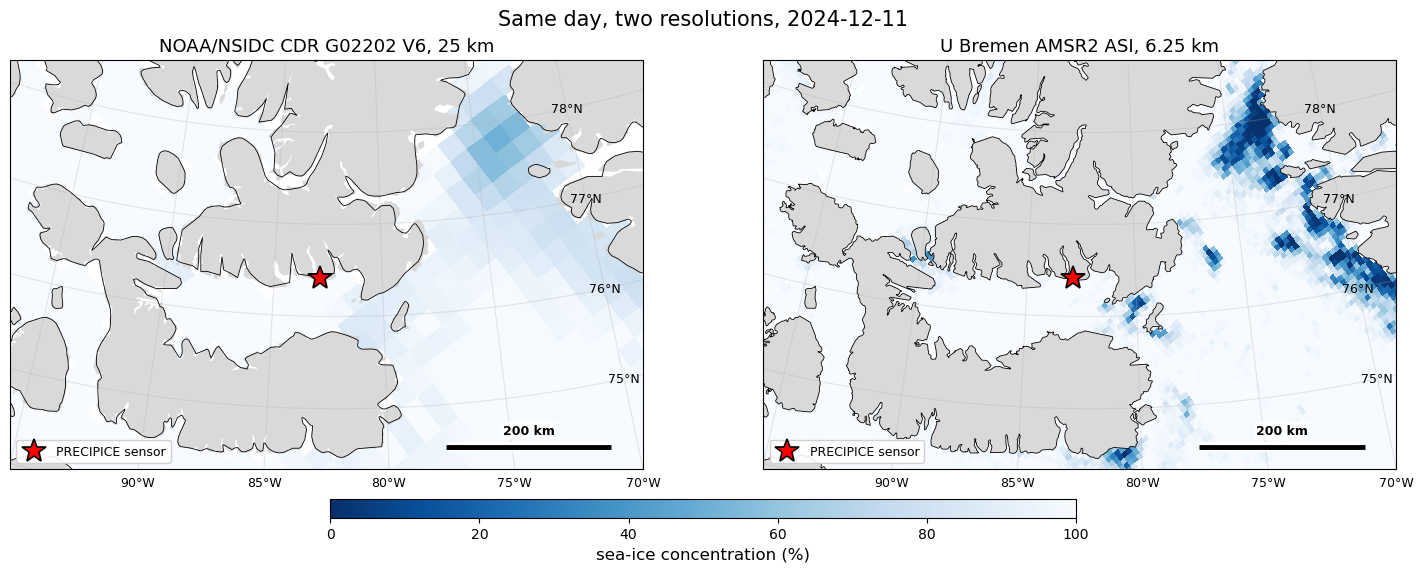

CDR   cell size 25.00 km, grid (448, 304)
AMSR2 cell size  6.25 km, grid (1792, 1216)


In [7]:
# ── 2.2. Side-by-side concentration: CDR 25 km vs AMSR2 ASI 6.25 km ──
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray

MAP_DATE = sic['sic_3x3'].idxmax()
EXTENT   = [-95, -70, 74, 78.5]                    # Jones Sound, same for both panels

# ---- left: the 25 km CDR granule for that date ----
cdr_path = [p for p in cdr_files
            if pd.to_datetime(re.search(r'_(\d{8})_', p.name).group(1),
                              format='%Y%m%d') == MAP_DATE.normalize()][0]
dm  = xr.open_dataset(cdr_path)
cdr = dm['cdr_seaice_conc'].isel(time=0).where(lambda a: (a >= 0) & (a <= 1)) * 100

# CDR grid: north polar stereographic on the Hughes 1980 ellipsoid, NOT WGS84.
cdr_proj = ccrs.Stereographic(central_latitude=90, central_longitude=-45, true_scale_latitude=70,
                              globe=ccrs.Globe(semimajor_axis=6378273, semiminor_axis=6356889.449))

# ---- right: the 6.25 km Bremen AMSR2 GeoTIFF for the same date ----
BR_SERVER = 'https://data.seaice.uni-bremen.de/amsr2/asi_daygrid_swath/n6250'
MON = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

def bremen_geotiff(date):
    "Download (cached) the U Bremen AMSR2 ASI 6.25 km GeoTIFF for a date. Login-free."
    d    = pd.Timestamp(date)
    dest = BR_DIR / f'asi-AMSR2-n6250-{d:%Y%m%d}-v5.4.tif'
    if not (dest.exists() and dest.stat().st_size > 0):
        url = f'{BR_SERVER}/{d:%Y}/{MON[d.month-1]}/Arctic/{dest.name}'
        print(f'downloading {dest.name} ...')
        urllib.request.urlretrieve(url, dest)
    return dest

br    = rioxarray.open_rasterio(bremen_geotiff(MAP_DATE)).isel(band=0)
brconc = br.where(br <= 100)                       # 0-100 = percent, 120 = land -> NaN
br_proj = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=70)   # EPSG:3413

# ---- plot ----
# Cartopy axes hold a fixed aspect, so the figure has to be shaped to match the map extent
# or matplotlib centres the panels and leaves a band of white above and below.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), layout='constrained',
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-82)})

panels = [
    (axes[0], dm['x'], dm['y'], cdr,    cdr_proj, 'NOAA/NSIDC CDR G02202 V6, 25 km',  '50m'),
    (axes[1], br['x'], br['y'], brconc, br_proj,  'U Bremen AMSR2 ASI, 6.25 km',      '10m'),
]
for ax, X, Y, Z, src_proj, title, coast_res in panels:
    ax.set_extent(EXTENT, crs=ccrs.PlateCarree())
    pcm = ax.pcolormesh(X, Y, Z, cmap='Blues_r', vmin=0, vmax=100,
                        transform=src_proj, shading='nearest', zorder=1)
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
    ax.coastlines(resolution=coast_res, lw=0.6, zorder=3)
    ax.plot(GF_LON, GF_LAT, marker='*', ms=18, color='red', markeredgecolor='k',
            markeredgewidth=1.2, transform=ccrs.PlateCarree(), zorder=5,
            linestyle='None', label='PRECIPICE sensor')
    gl = ax.gridlines(draw_labels=True, alpha=0.3, rotate_labels=False,
                      xlocs=range(-95, -69, 5), ylocs=range(74, 80),
                      xlabel_style={'size': 9}, ylabel_style={'size': 9})
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, fontsize=13)
    ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
    add_scalebar(ax, 200)

cbar = fig.colorbar(pcm, ax=axes.tolist(), orientation='horizontal',
                    fraction=0.06, pad=0.02, shrink=0.5, aspect=40)
cbar.set_label('sea-ice concentration (%)', fontsize=12)
fig.suptitle(f'Same day, two resolutions, {MAP_DATE:%Y-%m-%d}', fontsize=15)
fig.savefig(FIGS / f'grise_fiord_sic_resolution_{MAP_DATE:%Y%m%d}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'CDR   cell size {abs(float(dm["x"][1] - dm["x"][0]))/1000:5.2f} km, grid {cdr.shape}')
print(f'AMSR2 cell size {abs(float(br["x"][1] - br["x"][0]))/1000:5.2f} km, grid {brconc.shape}')
dm.close()

---
## 2.3 The record at the site

The same approach was applied to both products, which have different spatial resolutions, to extract sea-ice concentration time series at the same location over the same period. Top row is the 25 km CDR, bottom
row is the 6.25 km AMSR2. On the left, the cells each series is drawn from: nearest cell in red, 3x3 block
in violet, green markers on the cells that remain after the land mask. On the right, the two series in the same
colours, sharing axes between rows.

The AMSR2 3x3 spans 18.8 km, which fits inside a single CDR cell, so it samples the sound rather than
averaging across it. Daily AMSR2 files are about 170 KB, so the full record is roughly 75 MB.


In [8]:
# ── 2.3a. Extract the same series from the 6.25 km AMSR2 product ──
from concurrent.futures import ThreadPoolExecutor, as_completed

br_csv = SEA_ICE / 'grise_fiord_sic_bremen6km.csv'
BR_REEXTRACT = False                       # True to re-read every GeoTIFF

days = pd.date_range(sic.index.min(), sic.index.max(), freq='D')

# Locate the site on the AMSR2 grid (EPSG:3413, 6.25 km).
r0 = rioxarray.open_rasterio(bremen_geotiff(MAP_DATE)).isel(band=0)
b_to = Transformer.from_crs('EPSG:4326', 'EPSG:3413', always_xy=True)
bsx, bsy = b_to.transform(GF_LON, GF_LAT)
bxi = int(np.abs(r0['x'].values - bsx).argmin())
byi = int(np.abs(r0['y'].values - bsy).argmin())
BPX = float(abs(r0['x'][1] - r0['x'][0]))
print(f'AMSR2 nearest cell y={byi} x={bxi}, pixel {BPX/1000:.2f} km')

if br_csv.exists() and not BR_REEXTRACT:
    bsic = pd.read_csv(br_csv, parse_dates=['time']).set_index('time')
    print(f'loaded cached series from {br_csv.name}  ({len(bsic)} days)')
else:
    def grab(d):
        try:    return d, bremen_geotiff(d)
        except Exception:  return d, None      # a few days are missing on the server
    got = {}
    with ThreadPoolExecutor(max_workers=8) as ex:
        futs = [ex.submit(grab, d) for d in days]
        for i, f in enumerate(as_completed(futs), 1):
            d, path = f.result()
            if path is not None:
                got[d] = path
            if i % 50 == 0 or i == len(futs):
                print(f'  {i}/{len(futs)}', end='\r')
    rows = []
    for d in sorted(got):
        a = rioxarray.open_rasterio(got[d]).isel(band=0).values
        c   = float(a[byi, bxi])
        win = a[byi-1:byi+2, bxi-1:bxi+2].astype(float)
        win = np.where((win >= 0) & (win <= 100), win, np.nan)   # 120 = land
        rows.append((d, c if 0 <= c <= 100 else np.nan, np.nanmean(win)))
    bsic = pd.DataFrame(rows, columns=['time', 'sic_cell', 'sic_3x3']).set_index('time')
    bsic.to_csv(br_csv)
    print(f'\nwrote {br_csv.name}  ({len(bsic)} days, {len(days) - len(bsic)} missing)')


AMSR2 nearest cell y=1122 x=470, pixel 6.25 km
loaded cached series from grise_fiord_sic_bremen6km.csv  (455 days)


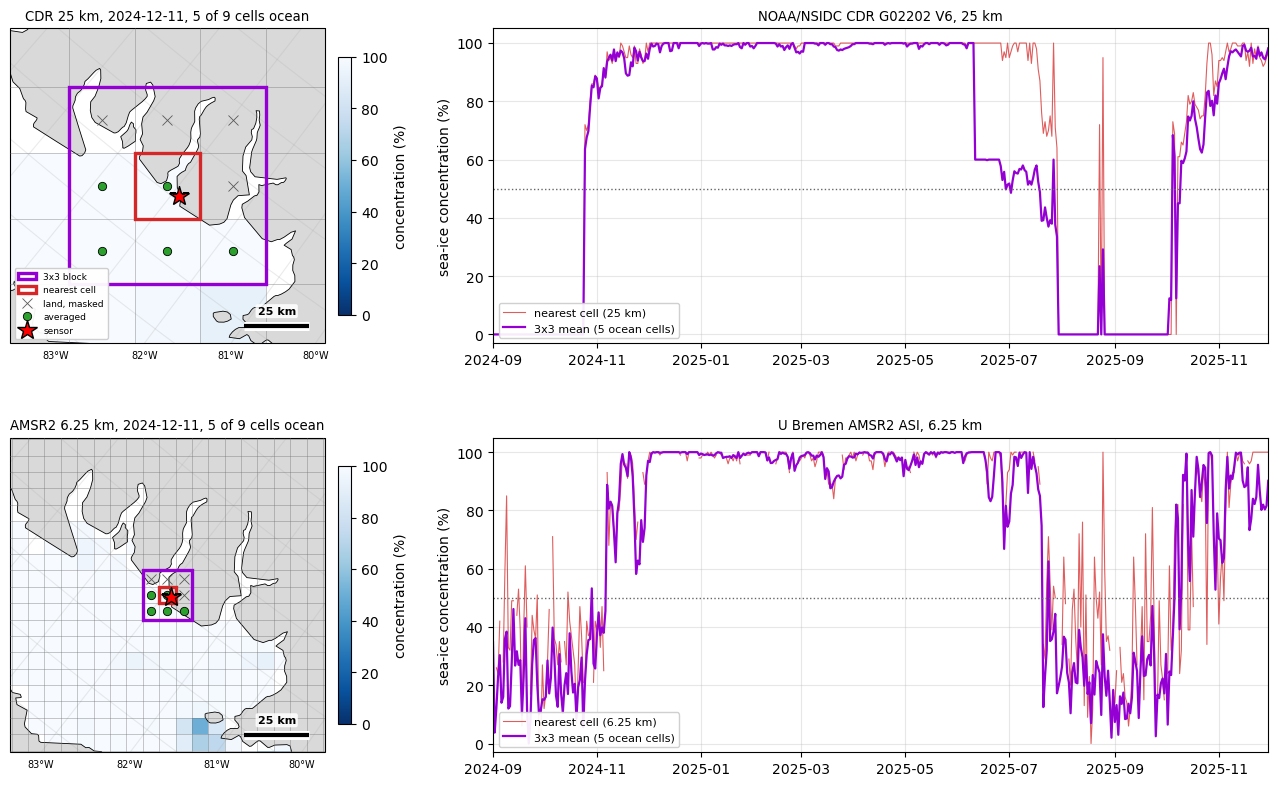

CDR   25 km: 3x3 spans   75 km, 5 ocean cells | below 15% on 120 of 456 days, above 80% on 259
AMSR2 6.25 km: 3x3 spans 18.8 km, 5 ocean cells | below 15% on  32 of 455 days, above 80% on 280


In [9]:
# ── 2.3b. Both products, cells and series, in one figure ──
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

C_CELL, C_3X3 = 'tab:red', 'darkviolet'      # same colours in every panel

def cell_map(ax, conc, gx, gy, xi, yi, proj, half, view, subtitle):
    """Draw the grid around the site, marking the nearest cell and the 3x3 block."""
    cx, cy = float(gx[xi]), float(gy[yi])
    ax.set_extent([cx - view, cx + view, cy - view, cy + view], crs=proj)
    pcm = ax.pcolormesh(gx, gy, conc, cmap='Blues_r', vmin=0, vmax=100,
                        transform=proj, shading='nearest', zorder=1)
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
    ax.coastlines(resolution='10m', lw=0.6, zorder=3)
    n = int(np.ceil((view - half) / (2 * half))) + 1
    for e in cx + half + 2 * half * np.arange(-n, n + 1):
        ax.plot([e, e], [cy - view, cy + view], color='0.45', lw=0.4, alpha=0.7,
                transform=proj, zorder=4)
    for e in cy + half + 2 * half * np.arange(-n, n + 1):
        ax.plot([cx - view, cx + view], [e, e], color='0.45', lw=0.4, alpha=0.7,
                transform=proj, zorder=4)
    ax.add_patch(Rectangle((cx - 3*half, cy - 3*half), 6*half, 6*half, transform=proj,
                           facecolor='none', edgecolor=C_3X3, lw=2.4, zorder=5, label='3x3 block'))
    ax.add_patch(Rectangle((cx - half, cy - half), 2*half, 2*half, transform=proj,
                           facecolor='none', edgecolor=C_CELL, lw=2.4, zorder=6, label='nearest cell'))
    used = 0
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            ok = bool(np.isfinite(conc.values[yi + dy, xi + dx]))
            used += ok
            ax.plot(float(gx[xi + dx]), float(gy[yi + dy]),
                    marker='o' if ok else 'x', ms=6 if ok else 7,
                    color='tab:green' if ok else '0.35',
                    markeredgecolor='k' if ok else '0.35', markeredgewidth=0.6,
                    linestyle='None', transform=proj, zorder=7,
                    label=('averaged' if ok else 'land, masked')
                          if (dy, dx) in ((0, 0), (-1, 0)) else None)
    ax.plot(GF_LON, GF_LAT, marker='*', ms=15, color='red', markeredgecolor='k',
            markeredgewidth=1.0, transform=ccrs.PlateCarree(), linestyle='None',
            zorder=8, label='sensor')
    gl = ax.gridlines(draw_labels=True, alpha=0.25, rotate_labels=False,
                      xlabel_style={'size': 7}, ylabel_style={'size': 7})
    gl.top_labels = gl.right_labels = False
    ax.set_title(f'{subtitle}, {used} of 9 cells ocean', fontsize=9.5)
    add_scalebar(ax, 25, fontsize=8, lw=3)
    return pcm, used

def series(ax, df, used, px_km, title):
    ax.plot(df.index, df['sic_cell'], lw=0.8, color=C_CELL, alpha=0.75,
            label=f'nearest cell ({px_km:g} km)')
    ax.plot(df.index, df['sic_3x3'], lw=1.6, color=C_3X3,
            label=f'3x3 mean ({used} ocean cells)')
    ax.axhline(50, color='0.4', ls=':', lw=1)
    ax.set_ylabel('sea-ice concentration (%)')
    ax.set_ylim(-3, 105)
    ax.set_title(title, fontsize=9.5)
    ax.legend(loc='lower left', framealpha=0.92, fontsize=8)
    ax.grid(alpha=0.3)

# ---- CDR backdrop, same day as the AMSR2 panel so the two are comparable ----
cdr_path = [f for f in cdr_files
            if pd.to_datetime(re.search(r'_(\d{8})_', f.name).group(1),
                              format='%Y%m%d') == MAP_DATE.normalize()][0]
with xr.open_dataset(cdr_path) as dm:
    cconc = dm['cdr_seaice_conc'].isel(time=0).where(lambda a: (a >= 0) & (a <= 1)) * 100
    cgx, cgy = dm['x'].values, dm['y'].values
    cday = pd.to_datetime(dm['time'].values[0])
cdr_proj = ccrs.Stereographic(central_latitude=90, central_longitude=-45, true_scale_latitude=70,
                              globe=ccrs.Globe(semimajor_axis=6378273, semiminor_axis=6356889.449))
# ---- AMSR2 backdrop ----
bconc = rioxarray.open_rasterio(bremen_geotiff(MAP_DATE)).isel(band=0)
bconc = bconc.where(bconc <= 100)
bgx, bgy = bconc['x'].values, bconc['y'].values
br_proj = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=70)

fig = plt.figure(figsize=(17, 9.4))
gs  = fig.add_gridspec(2, 2, width_ratios=[1, 1.7], wspace=0.14, hspace=0.30)
axA = fig.add_subplot(gs[0, 0], projection=cdr_proj)
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0], projection=br_proj)
axD = fig.add_subplot(gs[1, 1], sharex=axB, sharey=axB)

VIEW = 60_000.0                              # same ground in both rows, 120 km across
pcmA, usedA = cell_map(axA, cconc, cgx, cgy, xi, yi, cdr_proj, 12_500.0, VIEW,
                       f'CDR 25 km, {cday:%Y-%m-%d}')
series(axB, sic, usedA, 25, 'NOAA/NSIDC CDR G02202 V6, 25 km')
pcmC, usedC = cell_map(axC, bconc, bgx, bgy, bxi, byi, br_proj, BPX / 2, VIEW,
                       f'AMSR2 {BPX/1000:.2f} km, {MAP_DATE:%Y-%m-%d}')
series(axD, bsic, usedC, BPX / 1000, 'U Bremen AMSR2 ASI, 6.25 km')

axA.legend(loc='lower left', fontsize=6.5, framealpha=0.95)
axB.set_xlim(sic.index.min(), sic.index.max())
axD.set_xlabel('')
for ax, pcm in ((axA, pcmA), (axC, pcmC)):
    plt.colorbar(pcm, ax=ax, shrink=0.82, pad=0.03, label='concentration (%)')

fig.savefig(FIGS / 'grise_fiord_sic_summary.png', dpi=150, bbox_inches='tight')
plt.show()

for name, df, used, span in (('CDR   25 km', sic, usedA, 75), ('AMSR2 6.25 km', bsic, usedC, 18.8)):
    print(f'{name}: 3x3 spans {span:>4} km, {used} ocean cells | '
          f'below 15% on {int((df["sic_3x3"] < 15).sum()):3d} of {len(df)} days, '
          f'above 80% on {int((df["sic_3x3"] > 80).sum()):3d}')


---

## 2.4 ICESat-2, two products side by side

ICESat-2's ATLAS laser altimeter measures surface height directly. Here we compare two sea-ice products: **ATL10 (Sea Ice Freeboard)** and **ATL07 (Sea Ice Height)**. At this site, ATL10 contains no usable measurements, while ATL07 provides thousands of surface-height measurements within Jones Sound.

**ATL10 (left panel) has nothing at the site.** Freeboard is the height of ice *above the local sea surface*, so the algorithm needs (a) concentration above ~50%, (b) enough nearby open-water leads to define the sea-surface reference, and (c) segments at least 25 km from land. Jones Sound is landfast and narrower than 25 km, so it fails (b) and (c), and every one of the ~36k points in the search box comes back as fill. The nearest valid freeboard is a couple of hundred km south in mobile marginal ice, which is what the left panel shows.

**ATL07 (right panel) works.** It is the product one step upstream, reporting the surface height of each good ice or lead segment relative to the tide-free mean sea surface. It has no 25 km land-distance requirement, so it retains the landfast segments that ATL10 discards. The tracks were crossing the sound all along; they simply carried no freeboard. Pulling ATL07 for the same overpasses recovers thousands of good heights inside the sound, with the nearest within a few km of the sensor.

**One caveat in ATL07.** Over landfast ice, it stamps `height_segment_quality = 0` ("bad") on every segment even though the heights are fine and tightly clustered around 0.05 m. Filtering on that flag would throw away the whole dataset. We instead filter on finite height and a valid `height_segment_type`.

Both cells below need a free [Earthdata Login](https://urs.earthdata.nasa.gov/users/new).


In [10]:
# ── 2.4a. Download ATL10 and ATL07 overpasses ──
import earthaccess, h5py

IS2_BBOX = (-90.0, 75.5, -78.0, 77.5)              # (W, S, E, N) Jones Sound and its mouth
IS2_START, IS2_END = '2025-02-01', '2025-02-05'    # late winter, passes that cross the sound
N_GRANULES = 4                                     # ATL10 ~100 MB each, ATL07 ~300 MB each

def get_is2(short_name, dest_dir, n=N_GRANULES):
    "Download (cached) n ICESat-2 granules over the site. Skips entirely if files already exist."
    have = sorted(dest_dir.glob('*.h5'))
    if len(have) >= n:
        print(f'{short_name}: {len(have)} granules already cached, skipping download')
        return have
    earthaccess.login(persist=True)                # prompts once, then reads ~/.netrc
    gr = earthaccess.search_data(short_name=short_name, version='007',
                                 bounding_box=IS2_BBOX, temporal=(IS2_START, IS2_END))
    print(f'{short_name}: {len(gr)} granules intersect the box, downloading {min(n, len(gr))}')
    earthaccess.download(gr[:n], str(dest_dir))
    return sorted(dest_dir.glob('*.h5'))

atl10_files = get_is2('ATL10', IS2_DIR)
atl07_files = get_is2('ATL07', A7_DIR)
print(f'ATL10 {len(atl10_files)} files, {sum(f.stat().st_size for f in atl10_files)/1e9:.2f} GB')
print(f'ATL07 {len(atl07_files)} files, {sum(f.stat().st_size for f in atl07_files)/1e9:.2f} GB')

ATL10: 4 granules already cached, skipping download
ATL07: 4 granules already cached, skipping download
ATL10 4 files, 0.40 GB
ATL07 4 files, 1.36 GB


ATL10: 8,062 valid freeboard of 92,091 in-box segments, nearest 236 km from the sensor
ATL07: 26,338 valid heights   of 38,557 in-box segments, nearest 16.1 km from the sensor


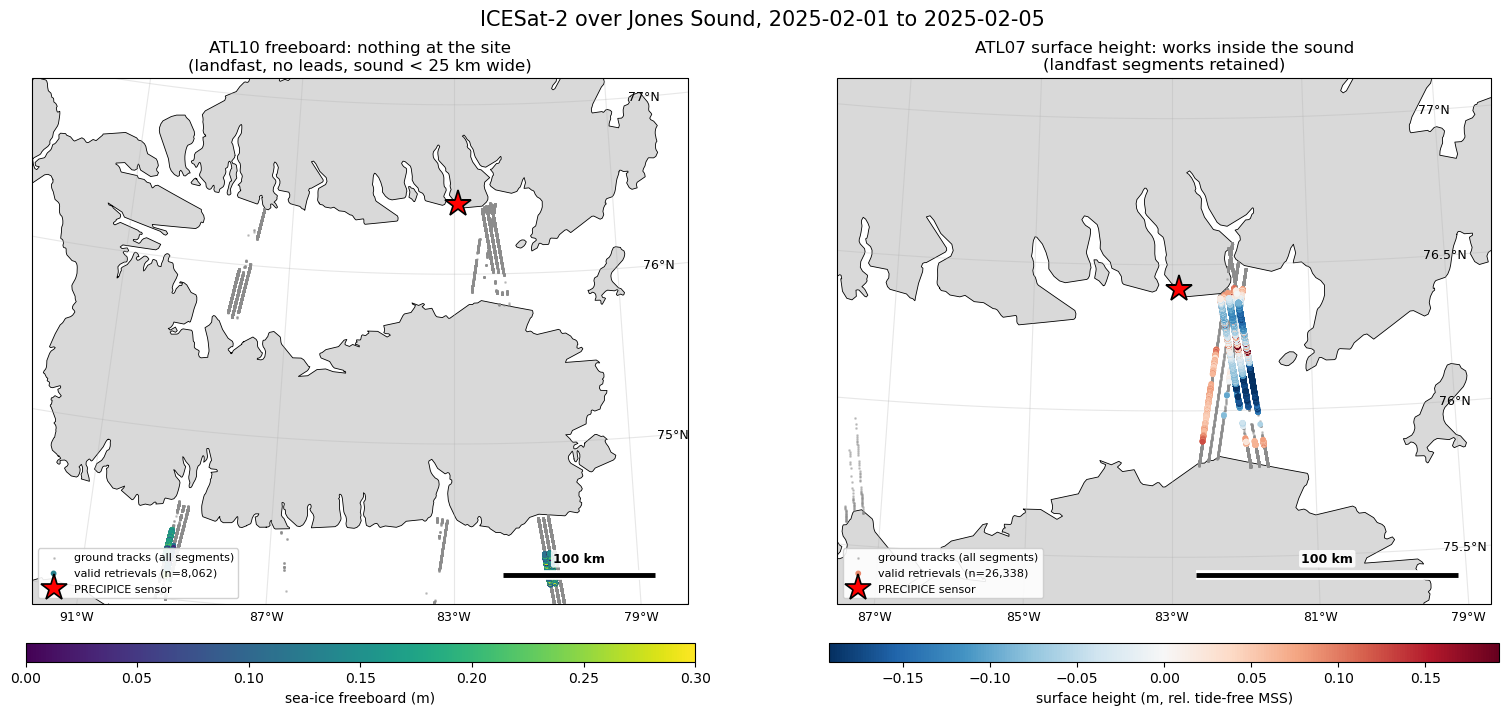


ATL07 median height -0.05 m rel. MSS, IQR -0.10 to -0.00 m across 2 overpasses


In [11]:
# ── 2.4b. Read both products and map them side by side ──
BEAMS = ['gt1l', 'gt1r', 'gt2l', 'gt2r', 'gt3l', 'gt3r']

# Different boxes on purpose. ATL10 has nothing at the site, so its panel has to reach south to
# show anything at all; ATL07 works inside the sound, so its panel zooms in on the sensor.
# The two spans are chosen to have the same width/height ratio so the panels render the same size.
FB_BBOX = (-92.0, 74.0, -78.0, 77.0)               # ATL10: site at top, valid freeboard near 74.3 N
A7_BBOX = (-87.5, 75.3, -78.7, 77.1)               # ATL07: Jones Sound, sensor in the middle

def read_atl10(box):
    "Return (track lon, track lat, DataFrame of valid freeboard). Fill value is 3.4e38."
    W, S, E, N = box
    tlat, tlon, recs = [], [], []
    for f in sorted(IS2_DIR.glob('*.h5')):
        with h5py.File(f, 'r') as h:
            for b in BEAMS:
                g = h.get(f'{b}/freeboard_segment')
                if g is None or 'beam_fb_height' not in g:
                    continue
                lat = g['latitude'][:]; lon = g['longitude'][:]; fb = g['beam_fb_height'][:]
                inbox = (lat >= S) & (lat <= N) & (lon >= W) & (lon <= E)
                tlat.append(lat[inbox]); tlon.append(lon[inbox])        # full track, fill included
                m = inbox & (fb < 1e30)                                  # valid freeboard only
                recs += list(zip([f.name[:29]]*m.sum(), [b]*m.sum(),
                                 lat[m].astype(float), lon[m].astype(float), fb[m].astype(float)))
    return (np.concatenate(tlon) if tlon else np.array([]),
            np.concatenate(tlat) if tlat else np.array([]),
            pd.DataFrame(recs, columns=['granule', 'beam', 'lat', 'lon', 'freeboard_m']))

def read_atl07(box):
    "Return (track lon, track lat, DataFrame of surface heights rel. tide-free MSS)."
    W, S, E, N = box
    tlat, tlon, recs = [], [], []
    for f in sorted(A7_DIR.glob('*.h5')):
        with h5py.File(f, 'r') as h:
            for b in BEAMS:
                ss = h.get(f'{b}/sea_ice_segments')
                if ss is None:
                    continue
                lat = ss['latitude'][:]; lon = ss['longitude'][:]
                ht  = ss['heights/height_segment_height'][:]
                typ = ss['heights/height_segment_type'][:]
                inbox = (lat >= S) & (lat <= N) & (lon >= W) & (lon <= E)
                tlat.append(lat[inbox]); tlon.append(lon[inbox])
                # NOT gating on height_segment_quality: it is 0 for every landfast segment
                # even though the heights are good. Finite height + valid type is the real filter.
                m = inbox & (np.abs(ht) < 100.0) & (typ != -1)
                recs += list(zip([f.name[:29]]*m.sum(), [b]*m.sum(),
                                 lat[m].astype(float), lon[m].astype(float), ht[m].astype(float)))
    return (np.concatenate(tlon) if tlon else np.array([]),
            np.concatenate(tlat) if tlat else np.array([]),
            pd.DataFrame(recs, columns=['granule', 'beam', 'lat', 'lon', 'surf_height_m']))

fb_tlon, fb_tlat, fbdf = read_atl10(FB_BBOX)
a7_tlon, a7_tlat, a7df = read_atl07(A7_BBOX)
fbdf.to_csv(SEA_ICE / 'grise_fiord_atl10_freeboard.csv', index=False)
a7df.to_csv(SEA_ICE / 'grise_fiord_atl07_surface_height.csv', index=False)

def km_to_site(d):
    dlat = d['lat'] - GF_LAT
    dlon = (d['lon'] - GF_LON) * np.cos(np.radians(GF_LAT))
    return 111.0 * np.sqrt(dlat**2 + dlon**2)

print(f'ATL10: {len(fbdf):,} valid freeboard of {fb_tlat.size:,} in-box segments'
      + (f', nearest {km_to_site(fbdf).min():.0f} km from the sensor' if len(fbdf) else ''))
print(f'ATL07: {len(a7df):,} valid heights   of {a7_tlat.size:,} in-box segments'
      + (f', nearest {km_to_site(a7df).min():.1f} km from the sensor' if len(a7df) else ''))

# ---- plot ----
is2_proj = ccrs.NorthPolarStereo(central_longitude=-83, true_scale_latitude=70)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), layout='constrained',
                         subplot_kw={'projection': is2_proj})

for ax, box, tlon, tlat, d, val, cmap, vlim, cblabel, title, steps in [
    (axes[0], FB_BBOX, fb_tlon, fb_tlat, fbdf, 'freeboard_m',   'viridis', (0, 0.3),
     'sea-ice freeboard (m)',
     'ATL10 freeboard: nothing at the site\n(landfast, no leads, sound < 25 km wide)', (4, 1)),
    (axes[1], A7_BBOX, a7_tlon, a7_tlat, a7df, 'surf_height_m', 'RdBu_r',  None,
     'surface height (m, rel. tide-free MSS)',
     'ATL07 surface height: works inside the sound\n(landfast segments retained)', (2, 0.5)),
]:
    W, S, E, N = box
    dlon, dlat = steps
    ax.set_extent([W, E, S, N], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=1)
    ax.coastlines(resolution='10m', lw=0.6, zorder=2)
    ax.scatter(tlon, tlat, s=1, color='0.55', alpha=0.4, transform=ccrs.PlateCarree(),
               zorder=3, label='ground tracks (all segments)')
    if len(d):
        if vlim is None:
            v = float(np.nanpercentile(np.abs(d[val]), 95)) or 0.3
            vlim = (-v, v)
        sc = ax.scatter(d['lon'], d['lat'], c=d[val], s=10, cmap=cmap,
                        vmin=vlim[0], vmax=vlim[1], transform=ccrs.PlateCarree(), zorder=4,
                        label=f'valid retrievals (n={len(d):,})')
        cb = fig.colorbar(sc, ax=ax, orientation='horizontal', shrink=0.85, pad=0.03, aspect=35)
        cb.set_label(cblabel, fontsize=10)
    ax.plot(GF_LON, GF_LAT, marker='*', ms=20, color='red', markeredgecolor='k',
            markeredgewidth=1.2, transform=ccrs.PlateCarree(), zorder=5,
            linestyle='None', label='PRECIPICE sensor')
    gl = ax.gridlines(draw_labels=True, alpha=0.3, rotate_labels=False,
                      xlocs=np.arange(-95, -69, dlon), ylocs=np.arange(74, 80, dlat),
                      xlabel_style={'size': 9}, ylabel_style={'size': 9})
    gl.top_labels = gl.right_labels = False
    ax.set_title(title, fontsize=12)
    ax.legend(loc='lower left', fontsize=8, framealpha=0.9)
    add_scalebar(ax, 100)

fig.suptitle(f'ICESat-2 over Jones Sound, {IS2_START} to {IS2_END}', fontsize=15)
fig.savefig(FIGS / 'grise_fiord_icesat2_atl10_vs_atl07.png', dpi=150, bbox_inches='tight')
plt.show()

if len(a7df):
    print(f'\nATL07 median height {a7df.surf_height_m.median():+.2f} m rel. MSS, '
          f'IQR {a7df.surf_height_m.quantile(.25):+.2f} to {a7df.surf_height_m.quantile(.75):+.2f} m '
          f'across {a7df.granule.nunique()} overpasses')

---
# 3. SWOT over Grise Fiord

SWOT (Surface Water and Ocean Topography, NASA/CNES, launched December 2022) carries KaRIn, a Ka-band radar that measures sea surface height across two ~50 km-wide swaths separated by a ~20 km gap.

### Which product

| Product | Posting | Use it for |
|---|---|---|
| **L2 LR SSH Expert** | 2 km | Default. Has SSHA, all corrections as separate variables, quality flags, and an `ice_conc` field. |
| L2 LR SSH Basic | 2 km | Same grid, fewer variables. |
| L2 LR SSH Unsmoothed | ~250 m native | Much closer to the GNSS-IR Fresnel footprint (~210 m), much noisier per pixel. No pre-computed SSHA, so use `ssh_karin_2 − mean_sea_surface_cnescls`. Split into `left` / `right` netCDF groups. |

Collection short name for `earthaccess` is **`SWOT_L2_LR_SSH_Expert_D`**. Landing page with the product
description documents is [PO.DAAC SWOT_L2_LR_SSH_Expert_D](https://podaac.jpl.nasa.gov/dataset/SWOT_L2_LR_SSH_Expert_D).
To browse granules visually first, use [Earthdata Search](https://search.earthdata.nasa.gov/search?q=SWOT_L2_LR_SSH_Expert).

### Access

Free [Earthdata Login](https://urs.earthdata.nasa.gov/users/new), then once:

```python
import earthaccess
earthaccess.login(persist=True)     # prompts, writes ~/.netrc, silent from then on
```

`earthaccess` handles the PO.DAAC cloud tokens. Do not put credentials in the notebook.

### Two things to watch for

1. **The crossover correction is not applied.** For LR products you must add it yourself:
   `ssha = ssha_karin_2 + height_cor_xover`. Skipping it leaves a several-cm inter-track bias. Variable
   definitions and correction conventions are set out in the
   [product documentation](https://podaac.jpl.nasa.gov/dataset/SWOT_L2_LR_SSH_Expert_D).
2. **Longitudes are stored 0-360.** Convert with `np.where(lon > 180, lon - 360, lon)` before anything
   expecting -180 to 180.

At this site, quality-filter on `ssha_karin_2_qual == 0` and, in ice season, on `ice_conc <= 15`.

### Which pass to plot

About 30 SWOT tracks cross Jones Sound in each 21-day cycle. Jones Sound is narrow enough that the swath
position determines how much of it is covered. Track 072 puts the site at the inner swath edge beside the
nadir gap and returns almost no usable data; Track 457 covers the sound, but the gap runs through its
middle; Track 184 places both swaths along the sound and covers it end to end.

The cell below downloads one granule into `data/swot/` and reuses it later. If you already have SWOT
granules elsewhere on disk, add those directories to `EXTRA_SWOT_DIRS` and it will search them first instead
of downloading anything.

In [12]:
# ── 3a. Get one SWOT granule over Grise Fiord ──

import earthaccess

SWOT_BBOX  = (-90.0, 75.5, -78.0, 77.5)            # (W, S, E, N) Jones Sound and its mouth
SWOT_TIME  = ('2025-08-15', '2025-08-17')          # open-water season
SHORT_NAME = 'SWOT_L2_LR_SSH_Expert_D'             # PO.DAAC collection; _2.0 names return nothing
SWOT_TRACK = '184'                                 # best-covered pass, see above. None = take the first hit

# Optional: directories where you already keep SWOT granules. Searched before downloading.
EXTRA_SWOT_DIRS = []                               # e.g. [Path.home() / 'data' / 'swot_tracks']

def find_swot(pattern='SWOT_L2_LR_SSH_Expert_*.nc'):
    for root in [SWOT_DIR, *EXTRA_SWOT_DIRS]:
        hits = sorted(Path(root).rglob(pattern)) if Path(root).exists() else []
        if hits:
            return hits
    return []

hits = find_swot()
if hits:
    swot_file = hits[0]
    print(f'using cached granule: {swot_file.name}   ({len(hits)} found)')
else:
    earthaccess.login(persist=True)                # prompts on first run only
    results = earthaccess.search_data(short_name=SHORT_NAME,
                                      bounding_box=SWOT_BBOX,
                                      temporal=SWOT_TIME)
    if SWOT_TRACK:                                 # granule name is ..._Expert_<cycle>_<pass>_<start>_...
        results = [g for g in results
                   if g.data_links()[0].split('/')[-1].split('_')[6] == SWOT_TRACK] or results
    print(f'{len(results)} granules match, downloading 1 (~34 MB)')
    earthaccess.download(results[:1], str(SWOT_DIR))
    swot_file = find_swot()[0]
    print(f'downloaded {swot_file.name}')

# Parse track and date out of the filename: SWOT_L2_LR_SSH_Expert_<cycle>_<pass>_<start>_<end>_<crid>_01.nc
parts      = swot_file.name.split('_')
swot_track = parts[6]
swot_date  = f'{parts[7][:4]}-{parts[7][4:6]}-{parts[7][6:8]}'
print(f'track {swot_track}, {swot_date}')

using cached granule: SWOT_L2_LR_SSH_Expert_037_184_20250816T213127_20250816T222256_PID0_01.nc   (1 found)
track 184, 2025-08-16


540 swath rows in region, 15,996 pixels pass QC and the ice filter


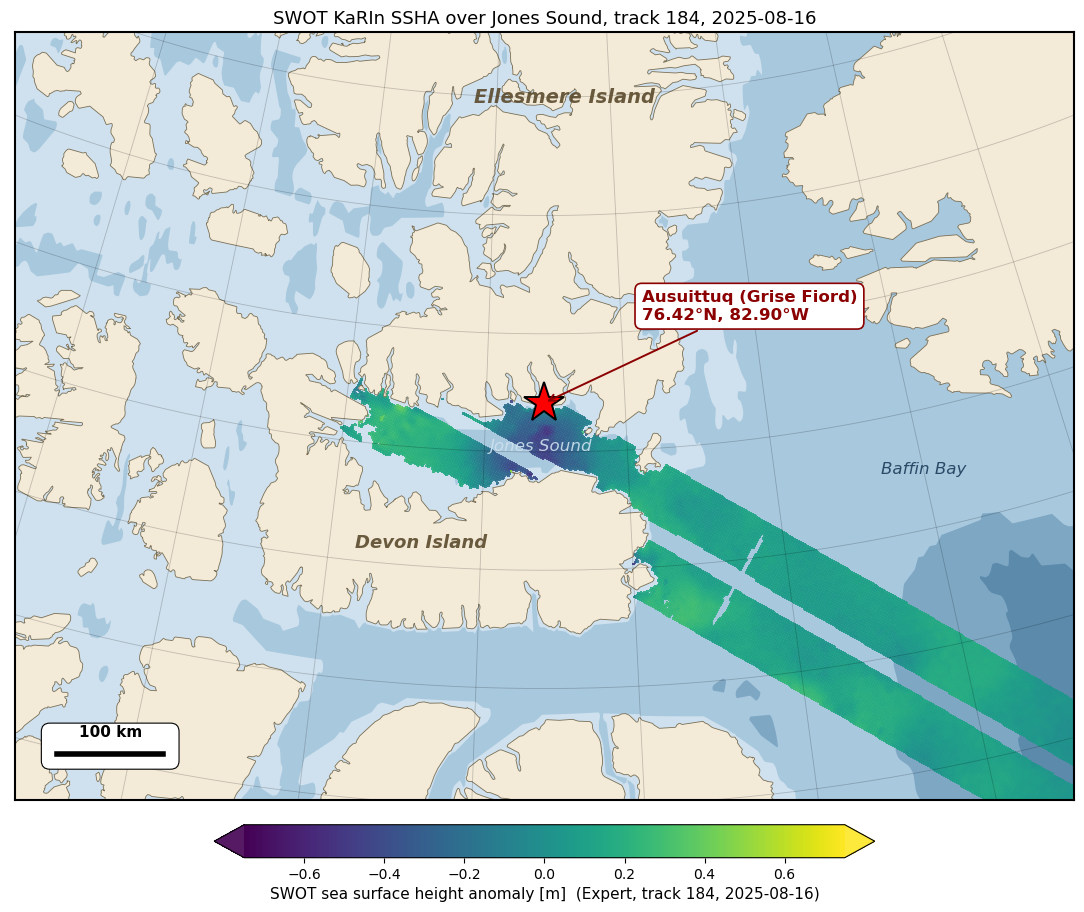

In [13]:
# ── 3b. Read it, apply the corrections, project onto the Jones Sound base ──

with xr.open_dataset(swot_file, decode_times=False) as ds:
    lon  = ds['longitude'].values
    lat  = ds['latitude'].values
    ssha = (ds['ssha_karin_2'] + ds['height_cor_xover']).values    # crossover correction is NOT pre-applied
    qual = ds['ssha_karin_2_qual'].values
    ice  = ds['ice_conc'].values

lon = np.where(lon > 180, lon - 360, lon)                          # 0-360 -> -180..180

# Trim to rows crossing the region before projecting. The full orbit is ~10k rows and slow otherwise.
keep = ((lat >= 73) & (lat <= 80) & (lon >= -100) & (lon <= -65)).any(axis=1)
lon, lat, ssha, qual, ice = lon[keep], lat[keep], ssha[keep], qual[keep], ice[keep]

ssha = np.ma.masked_where((qual != 0) | (ice > 15) | ~np.isfinite(ssha), ssha)
print(f'{ssha.shape[0]} swath rows in region, '
      f'{int((~np.ma.getmaskarray(ssha)).sum()):,} pixels pass QC and the ice filter')

swot_x, swot_y = ltr.transform(lon, lat)

# ── plot ──
ALPHA = 0.9          # viridis reads strongly over the pale basemap; keep it near-opaque
fig, ax = plt.subplots(figsize=(11, 9))
ax.set_facecolor('#cfe1ee')

for z, (polys, color) in enumerate(inset_bathy_patches, start=1):
    ax.add_collection(PatchCollection([MplPoly(p, closed=True) for p in polys],
                                      facecolor=color, edgecolor='none', zorder=z))

# SWOT sits under the land layer so the coastline stays readable on top of it
mesh = ax.pcolormesh(swot_x, swot_y, ssha, cmap='viridis', vmin=-0.75, vmax=0.75,
                     alpha=ALPHA, shading='nearest', zorder=9)

ax.add_collection(PatchCollection([MplPoly(p, closed=True) for p in land_patches],
                                  facecolor='#f3ead8', edgecolor='#7a6f55',
                                  linewidth=0.6, zorder=10))

ax.plot(gf_x, gf_y, marker='*', markersize=30, color='red',
        markeredgecolor='black', markeredgewidth=1.4, zorder=20)
ax.annotate('Ausuittuq (Grise Fiord)\n76.42°N, 82.90°W', xy=(gf_x, gf_y),
            xytext=(70, 60), textcoords='offset points',
            fontsize=12, fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='darkred', lw=1.2),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.4), zorder=21)

for lon_l, lat_l, lbl, fs, col, kind in [
    (-82, 79.0,  'Ellesmere Island', 14, '#5b4a2c', 'land'),
    (-87, 75.2,  'Devon Island',     13, '#5b4a2c', 'land'),
    (-83, 76.05, 'Jones Sound',      12, '#cfe1ee', 'sea'),   # light: it sits on the dark swath
    (-70, 75.5,  'Baffin Bay',       12, '#1c3d5a', 'sea'),
]:
    xs_, ys_ = ltr.transform(lon_l, lat_l)
    ax.text(xs_, ys_, lbl, ha='center', va='center', fontsize=fs, style='italic',
            fontweight=('bold' if kind == 'land' else 'normal'),
            color=col, alpha=0.9, zorder=15)

ax.set_xlim(gf_x - half_local, gf_x + half_local)
ax.set_ylim(gf_y - half_local * 0.75, gf_y + half_local * 0.7)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_zorder(100); sp.set_linewidth(1.5)

# graticule
for la in range(73, 81):
    _l = np.linspace(-110, -55, 400)
    ax.plot(*ltr.transform(_l, np.full_like(_l, la)),
            color='black', alpha=0.20, lw=0.6, zorder=11)
for lo in range(-100, -64, 5):
    _l = np.linspace(70, 85, 200)
    ax.plot(*ltr.transform(np.full_like(_l, lo), _l),
            color='black', alpha=0.20, lw=0.6, zorder=11)

# 100 km scale bar
xl, yl = ax.get_xlim(), ax.get_ylim()
bx, by = xl[0] + (xl[1]-xl[0])*0.04, yl[0] + (yl[1]-yl[0])*0.06
ax.add_patch(FancyBboxPatch((bx - 15e3, by - (yl[1]-yl[0])*0.02), 130e3, (yl[1]-yl[0])*0.06,
                            boxstyle='round,pad=0.0,rounding_size=8000',
                            fc='white', ec='black', lw=0.8, zorder=49))
ax.plot([bx, bx + 100e3], [by, by], 'k-', lw=4, zorder=50)
ax.text(bx + 50e3, by + (yl[1]-yl[0])*0.018, '100 km', ha='center', va='bottom',
        fontsize=11, fontweight='bold', zorder=50)

cbar = fig.colorbar(mesh, ax=ax, orientation='horizontal', extend='both',
                    fraction=0.04, pad=0.03)
cbar.set_label(f'SWOT sea surface height anomaly [m]  (Expert, track {swot_track}, {swot_date})',
               fontsize=11)
cbar.solids.set_alpha(1.0)

ax.set_title(f'SWOT KaRIn SSHA over Jones Sound, track {swot_track}, {swot_date}', fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / f'grise_fiord_swot_{swot_track}_{swot_date}.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Notes

**Nothing here is machine-specific.** `PROJECT_ROOT` is set from the notebook location, and downloaded
files go into the gitignored `data/` directory.

- The site coordinate is a Google Earth estimate rather than a surveyed position. Replace it with the
  surveyed coordinates when available.
- CHS gauge counts change as stations are commissioned or retired, so the numbers in the legend may
  differ between runs.

**Where to read more**

- SWOT mission and product docs: [PO.DAAC SWOT portal](https://podaac.jpl.nasa.gov/SWOT)
- SWOT data tutorials from PO.DAAC: [podaac/tutorials](https://podaac.github.io/tutorials/)
- `earthaccess` docs: [earthaccess.readthedocs.io](https://earthaccess.readthedocs.io/)
- NOAA/NSIDC sea-ice CDR G02202 V6: [nsidc.org/data/g02202](https://nsidc.org/data/g02202)
- U Bremen AMSR2 sea ice: [seaice.uni-bremen.de](https://seaice.uni-bremen.de/sea-ice-concentration/)
- ICESat-2 ATL07/10/12 product pages: [nsidc.org/data/icesat-2](https://nsidc.org/data/icesat-2)
- Natural Earth vector data: [naturalearthdata.com](https://www.naturalearthdata.com/)

---
If you spot a mistake, please email **elena.savidge@gmail.com**